Synthesizing the word 'transformers'...
Synthesizing phoneme 1: unvoiced
Synthesizing phoneme 2: voiced
Synthesizing phoneme 3: voiced
Synthesizing phoneme 4: voiced
Synthesizing phoneme 5: unvoiced
Synthesizing phoneme 6: unvoiced
Synthesizing phoneme 7: voiced
Synthesizing phoneme 8: voiced
Synthesizing phoneme 9: voiced
Synthesizing phoneme 10: unvoiced


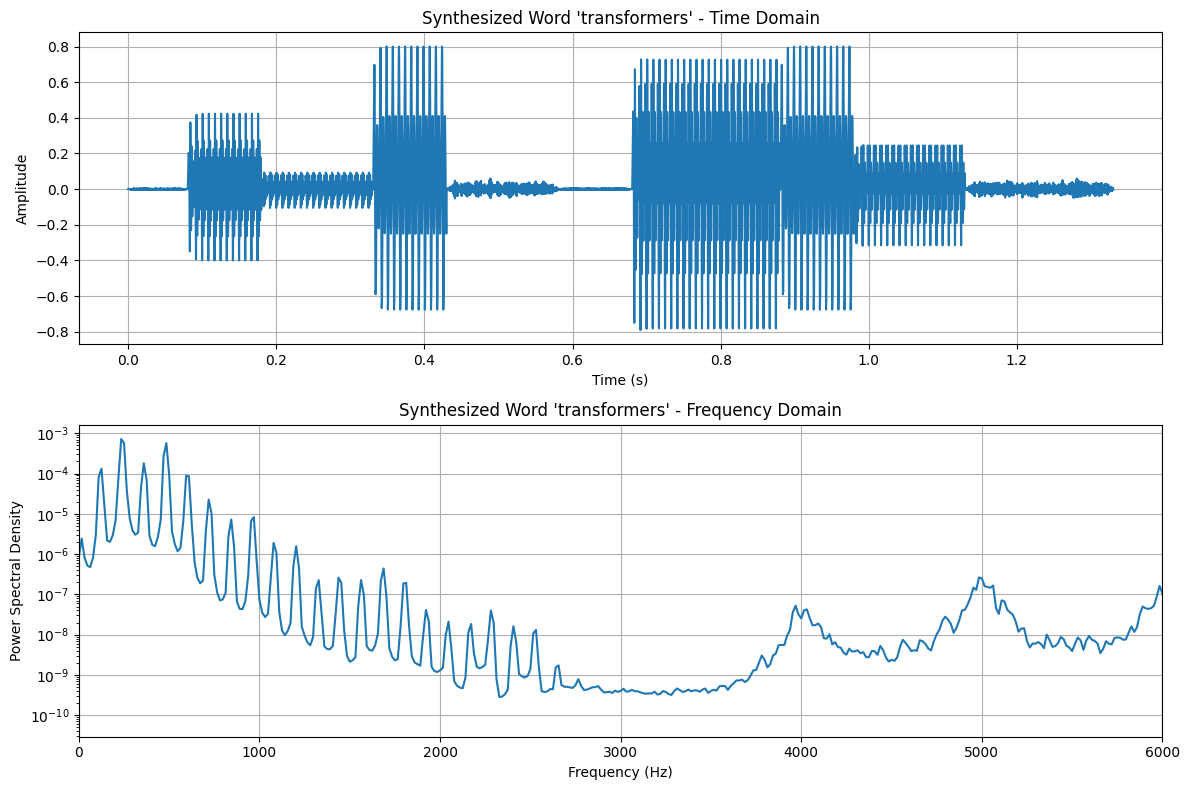

Synthesis complete! Audio saved as 'synthesized_transformers.wav'


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

def generate_glottal_pulse(duration, sample_rate, fundamental_freq):
    
    t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
    
    # Create pulse train for voiced sounds
    pulse_train = np.zeros_like(t)
    pulse_period = int(sample_rate / fundamental_freq)
    
    # Create a more realistic glottal pulse shape
    for i in range(0, len(t), pulse_period):
        if i + pulse_period <= len(t):
            # Rosenberg glottal pulse model
            pulse_width = int(pulse_period * 0.4)
            for j in range(pulse_width):
                if j < pulse_width * 0.6:
                    pulse_train[i + j] = 0.5 * (1 - np.cos(np.pi * j / (pulse_width * 0.6)))
                else:
                    pulse_train[i + j] = np.cos(np.pi * (j - pulse_width * 0.6) / (pulse_width * 0.4))
    
    return pulse_train, t

def generate_noise(duration, sample_rate):
    """Generate noise for unvoiced sounds"""
    t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
    noise = np.random.normal(0, 1, len(t))
    
    # Apply fade in/out to avoid clicks
    fade_samples = int(0.01 * sample_rate)
    noise[:fade_samples] *= np.linspace(0, 1, fade_samples)
    noise[-fade_samples:] *= np.linspace(1, 0, fade_samples)
    
    return noise, t

def design_formant_filter(frequencies, bandwidths, sample_rate, gain=1.0):
    """Design a formant filter using second-order sections"""
    sos = []
    for f, bw in zip(frequencies, bandwidths):
        omega = 2 * np.pi * f / sample_rate
        bw_digital = 2 * np.pi * bw / sample_rate
        
        r = np.exp(-bw_digital / 2)
        theta = omega
        
        b = [gain ** (1/len(frequencies))]
        a = [1, -2 * r * np.cos(theta), r * r]
        
        sos.append([b[0], 0, 0, a[0], a[1], a[2]])
    
    return np.array(sos)

def apply_formant_filter(input_signal, sos, sample_rate):
    """Apply formant filter to input signal"""
    output = input_signal.copy()
    
    # Apply each formant filter in cascade
    for section in sos:
        b = section[0:3]
        a = section[3:6]
        output = signal.lfilter(b, a, output)
    
    return output

def synthesize_phoneme(phoneme_type, duration, sample_rate, fundamental_freq=None):
    """Synthesize a single phoneme"""
    
    if phoneme_type == 'silence':
        return np.zeros(int(sample_rate * duration))
    
    elif phoneme_type == 'voiced':
        excitation, t = generate_glottal_pulse(duration, sample_rate, fundamental_freq)
        
    elif phoneme_type == 'unvoiced':
        excitation, t = generate_noise(duration, sample_rate)
    
    else:
        raise ValueError(f"Unknown phoneme type: {phoneme_type}")
    
    return excitation

def synthesize_word_transformers(sample_rate=16000, fundamental_freq=120):
    """Synthesize the word 'transformers' using source-filter model"""
    
    phonemes = [
        {'type': 'unvoiced', 'duration': 0.08, 'formants': []},                
        {'type': 'voiced', 'duration': 0.1, 'formants': [600, 1200, 2400]},   
        {'type': 'voiced', 'duration': 0.15, 'formants': [700, 1800, 2500]},  
        {'type': 'voiced', 'duration': 0.1, 'formants': [250, 1700, 2300]},   
        {'type': 'unvoiced', 'duration': 0.15, 'formants': [4000, 5000, 6000]},
        {'type': 'unvoiced', 'duration': 0.1, 'formants': []},                 
        {'type': 'voiced', 'duration': 0.2, 'formants': [500, 1000, 2500]},   
        {'type': 'voiced', 'duration': 0.1, 'formants': [250, 1700, 2300]},   
        {'type': 'voiced', 'duration': 0.15, 'formants': [500, 1500, 2500]},  
        {'type': 'unvoiced', 'duration': 0.2, 'formants': [4000, 5000, 6000]} 
    ]
    
    bandwidths = [80, 100, 120]
    synthesized_audio = []
    
    for i, phoneme in enumerate(phonemes):
        print(f"Synthesizing phoneme {i+1}: {phoneme['type']}")
        
        if phoneme['type'] == 'voiced':
            excitation = synthesize_phoneme('voiced', phoneme['duration'], sample_rate, fundamental_freq)
        else:
            excitation = synthesize_phoneme('unvoiced', phoneme['duration'], sample_rate)
        
        if phoneme['formants']:
            sos = design_formant_filter(phoneme['formants'], bandwidths, sample_rate)
            filtered_signal = apply_formant_filter(excitation, sos, sample_rate)
        else:
            filtered_signal = excitation
        
        synthesized_audio.append(filtered_signal)
    
    full_audio = np.concatenate(synthesized_audio)
    full_audio = full_audio / np.max(np.abs(full_audio)) * 0.8
    
    return full_audio


def plot_signals(signal_array, sample_rate, title):
    """Plot the synthesized signal in time and frequency domains"""
    t = np.linspace(0, len(signal_array)/sample_rate, len(signal_array))
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    ax1.plot(t, signal_array)
    ax1.set_title(f'{title} - Time Domain')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Amplitude')
    ax1.grid(True)
    
    f, Pxx = signal.welch(signal_array, sample_rate, nperseg=1024)
    ax2.semilogy(f, Pxx)
    ax2.set_title(f'{title} - Frequency Domain')
    ax2.set_xlabel('Frequency (Hz)')
    ax2.set_ylabel('Power Spectral Density')
    ax2.grid(True)
    ax2.set_xlim(0, 6000)
    
    plt.tight_layout()
    plt.show()


# Main execution
if __name__ == "__main__":
    # Parameters
    SAMPLE_RATE = 16000
    FUNDAMENTAL_FREQ = 120  # Hz (pitch for voiced sounds)
    
    # Synthesize the word "transformers"
    print("Synthesizing the word 'transformers'...")
    transformers_audio = synthesize_word_transformers(SAMPLE_RATE, FUNDAMENTAL_FREQ)
    
    # Plot the results
    plot_signals(transformers_audio, SAMPLE_RATE, "Synthesized Word 'transformers'")
    
    # Save as WAV file
    wavfile.write("synthesized_transformers.wav", SAMPLE_RATE, 
                  (transformers_audio * 32767).astype(np.int16))
    
    print("Synthesis complete! Audio saved as 'synthesized_transformers.wav'")


In [14]:
from IPython.display import Audio, display

print("\n🎧 Synthesized Audio: 'transformers'")
display(Audio(transformers_audio, rate=SAMPLE_RATE))



🎧 Synthesized Audio: 'transformers'


In [19]:
def plot_filter_effects():
    """Plot original source vs filtered signal to analyze filter effects"""
    
    # Synthesize a single voiced phoneme for analysis
    duration = 0.1
    sample_rate = 16000
    fundamental_freq = 120
    
    # Generate excitation source
    excitation, t = generate_glottal_pulse(duration, sample_rate, fundamental_freq)

    # Design formant filter (vowel 'a' formants)
    formant_freqs = [700, 1220, 2600]
    bandwidths = [80, 100, 120]
    sos = design_formant_filter(formant_freqs, bandwidths, sample_rate)
    
    # Apply filter
    filtered_signal = apply_formant_filter(excitation, sos, sample_rate)

    # Plot comparison
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # Time domain - excitation
    ax1.plot(t, excitation)
    ax1.set_title('Glottal Pulse Excitation (Time Domain)')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Amplitude')
    ax1.grid(True)
    
    # Time domain - filtered
    ax2.plot(t, filtered_signal)
    ax2.set_title('Filtered Speech Signal (Time Domain)')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Amplitude')
    ax2.grid(True)

    # Frequency domain - excitation
    f_exc, Pxx_exc = signal.welch(excitation, sample_rate, nperseg=1024)
    ax3.semilogy(f_exc, Pxx_exc)
    ax3.set_title('Excitation Spectrum')
    ax3.set_xlabel('Frequency (Hz)')
    ax3.set_ylabel('Power Spectral Density')
    ax3.grid(True)
    ax3.set_xlim(0, 4000)
    
    # Frequency domain - filtered
    f_filt, Pxx_filt = signal.welch(filtered_signal, sample_rate, nperseg=1024)
    ax4.semilogy(f_filt, Pxx_filt)
    ax4.set_title('Filtered Signal Spectrum (Formants Visible)')
    ax4.set_xlabel('Frequency (Hz)')
    ax4.set_ylabel('Power Spectral Density')
    ax4.grid(True)
    ax4.set_xlim(0, 4000)
